# 3.3. Odometry-based motion model

**Odometry** provides an estimate of the robot motion from its proprioceptive sensors, typically the **wheel encoders** in a differential-drive robot. In practice, the encoders measure how much each wheel has rotated over a short time interval, and this information can be converted into an incremental displacement of the robot.

As a curiosity, the term *odometry* comes from the Greek words ὁδός (*odos*, route) and μέτρον (*metron*, measurement), literally meaning *measurement of the route*.

<center><figure style="text-align:center">
    <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_motion/images/fig3-3-wheel_encoder.png" width="215" alt="">&emsp;
    <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_motion/images/fig3-3-encoder.png" width="500" alt="">  
  <figcaption>Fig. 1: Example of a wheel encoder used to sum pulses and compute the robot pose.</figcaption>
</figure></center>


### From encoder pulses to wheel rotation

An incremental encoder generates a number of pulses as the wheel rotates. If the encoder provides $n_{\text{total}}$ pulses per complete revolution, the angular increment associated with a single pulse is

$$
\alpha = \frac{2\pi}{n_{\text{total}}}
\qquad \text{(radians)}.
$$

Therefore, if $n_R$ and $n_L$ pulses are detected for the right and left wheels during a time interval $\Delta t$, their corresponding angular increments are

$$
\Delta \varphi_R = n_R \alpha,
\qquad
\Delta \varphi_L = n_L \alpha.
$$

These angular increments can be converted into the distances traveled by each wheel:

$$
\Delta s_R = r_R \Delta \varphi_R,
\qquad
\Delta s_L = r_L \Delta \varphi_L,
$$

where $r_R$ and $r_L$ are the radii of the right and left wheels, respectively.



### From wheel motion to robot motion

Assuming a differential-drive robot and constant curvature during the short motion interval, the displacement of the midpoint of the wheel axis is characterized by two quantities:

$$
\Delta s = \frac{\Delta s_R + \Delta s_L}{2},
$$

which represents the distance traveled along the arc by the midpoint of the wheel axis, and

$$
\Delta \theta =
\frac{\Delta s_R - \Delta s_L}{l},
$$

which represents the change in robot orientation, with $l$ being the distance between the wheels.

For $\Delta\theta \neq 0$, the robot follows an arc of radius

$$
R = \frac{\Delta s}{\Delta\theta}.
$$

The corresponding pose increment, expressed in the robot local reference frame, is then

$$
\Delta \mathbf{x}_t^{\mathrm{odo}}
=
\begin{bmatrix}
\Delta x_t \\
\Delta y_t \\
\Delta \theta_t
\end{bmatrix}
=
\begin{bmatrix}
\dfrac{\Delta s}{\Delta\theta}\sin(\Delta\theta) \\
\dfrac{\Delta s}{\Delta\theta}\left(1-\cos(\Delta\theta)\right) \\
\Delta\theta
\end{bmatrix}.
$$

If $\Delta\theta = 0$, both wheels have traveled the same distance and the robot moves along a straight line:

$$
\Delta \mathbf{x}_t^{\mathrm{odo}}
=
\begin{bmatrix}
\Delta s \\
0 \\
0
\end{bmatrix}.
$$

Thus, the complete process can be summarized as

$$
(\Delta\varphi_R,\Delta\varphi_L)
\rightarrow
(\Delta s_R,\Delta s_L)
\rightarrow
(\Delta s,\Delta\theta)
\rightarrow
\Delta\mathbf{x}_t^{\mathrm{odo}}.
$$



### Accumulating odometry

The firmware of the robotic base typically performs these computations at a **high rate** (e.g. **100 Hz**), generating a sequence of small pose increments. These increments are accumulated using the **composition of poses**, a tool already introduced in previous sections:

$$
\mathbf{x}_t^{\mathrm{odo}}
=
\mathbf{x}_{t-1}^{\mathrm{odo}}
\oplus
\Delta\mathbf{x}_t^{\mathrm{odo}}.
$$

The resulting odometry pose can then be made available to the rest of the robotic system at a lower rate (e.g. **10 Hz**).

<center><figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_motion/images/fig3-3-odometry_compositions.png" alt="" width="700px">
  <figcaption>Fig. 2: Example of composition of poses based on odometry.</figcaption>
</figure></center>

Therefore, between two odometry poses reported by the robotic base, several smaller pose increments may have been internally computed and accumulated by the firmware. For example, if the internal computation runs at 100 Hz while odometry is reported at 10 Hz, approximately 10 internal pose increments are accumulated between two consecutive reported odometry poses.


# The motion model

The **odometry motion model** uses the pose increment obtained from two consecutive odometry readings as the input to the motion model. Although odometry is technically a measurement rather than a control command, it is treated as the model input for convenience.

The odometry increment between times $t-1$ and $t$ is defined as

$$
\Delta \mathbf{x}_t^{\mathrm{odo}}
=
(\ominus \mathbf{x}_{t-1}^{\mathrm{odo}})
\oplus
\mathbf{x}_t^{\mathrm{odo}}
=
\begin{bmatrix}
\Delta x_t \\
\Delta y_t \\
\Delta \theta_t
\end{bmatrix}.
$$

Therefore, the odometry motion model can be expressed as

$$
\mathbf{x}_t
=
g_o
\left(
\mathbf{x}_{t-1},
\Delta \mathbf{x}_t^{\mathrm{odo}}
\right),
$$

where $\mathbf{x}_{t-1}$ is the previous robot pose and
$\mathbf{u}_t=\Delta \mathbf{x}_t^{\mathrm{odo}}$ is the pose increment measured by odometry.

In this work we are going to play with the **probabilistic** variant of this motion model using two different forms:

- **Analytical form**, where the odometry input is directly represented as a pose increment:

$$
\Delta \mathbf{x}_t^{\mathrm{odo}}
=
\begin{bmatrix}
\Delta x_t \\
\Delta y_t \\
\Delta \theta_t
\end{bmatrix}.
$$

- **Sample-based form**, where the same motion is decomposed into an initial rotation, a straight-line displacement, and a final rotation:

$$
\mathbf{u}_t^{\mathrm{odo}} =
\begin{bmatrix}
\bar{\theta}_1 \\
\bar{d} \\
\bar{\theta}_2
\end{bmatrix}.
$$

> ℹ️ **Usage:** The <b><i>velocity motion model</i></b> is mainly useful when the robot motion is described through commanded linear and angular velocities, as is common in motion planning. In contrast, the <b><i>odometry motion model</i></b> uses the motion actually measured by the robot sensors and is therefore particularly suitable for keeping track of the robot pose. However, odometry information is only available after the corresponding motion has been measured.

In [1]:
# In case of using Google Colab, mount Google Drive and enable interactive plots
try:
    from google.colab import drive, output
    drive.mount('/content/drive')
    # Change directory to this chapter's folder in your Drive copy of the course repo:
    %cd '/content/drive/MyDrive/Colab Notebooks/uma_robotics_2027/Chapter 03. Robot motion'
    %pip install -q ipympl
    # Make matplotlib detect the freshly installed ipympl backend:
    from matplotlib.backends.registry import backend_registry
    backend_registry.__init__()
    output.enable_custom_widget_manager()
except ImportError:
    pass

%matplotlib widget

# IMPORTS
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, clear_output
import time

import sys
sys.path.append("..")
from utils.DrawRobot import DrawRobot
from utils.PlotEllipse import PlotEllipse
from utils.pause import pause
from utils.Jacobians import J1, J2
from utils.tcomp import tcomp

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/uma_robotics_2027/Chapter 03. Robot motion
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.7 MB/s eta 0:00:00


## <font color="green">OPTIONAL</font>

<font color="green">
Let's reproduce the odometry computation performed by the robot base firmware!</font>


1. <font color="green">Implement a function that, given the encoder pulses detected in both wheels, computes their angular increments $\Delta\varphi_R$ and $\Delta\varphi_L$, and the corresponding wheel displacements $\Delta s_R$ and $\Delta s_L$.</font>

2. <font color="green">Implement a second function that computes the arc length $\Delta s$ and heading change $\Delta\theta$, and uses them to obtain the odometry pose increment $\Delta\mathbf{x}_t^{\mathrm{odo}} = [\Delta x_t, \Delta y_t, \Delta\theta_t]^T$. Remember to handle the straight-line case ($\Delta\theta=0$).</font>

3. <font color="green">Finally, given two sequences of encoder pulse counts (one for each wheel) and an initial robot pose, use the previous functions to compute the odometry pose increment for each pair of pulse counts. Starting from the initial pose, **update the robot pose after each increment using pose composition**. Return the complete sequence of estimated poses and the final odometry pose.
</font>

<span style="color:green">***END OF OPTIONAL PART***</span>

## 3.3.1 Analytic form

As we did in Chapter 3.1, the analytic form of the odometry motion model uses the **composition of poses** to model the robot motion. In this formulation, only the pose increment between two odometry readings is considered, without explicitly modeling the trajectory followed between them.

As in the **velocity motion model**, the robot pose is represented by a Gaussian distribution:

$$
\mathbf{x}_t \sim \mathcal{N}
\left(
\bar{\mathbf{x}}_t,
\Sigma_{\mathbf{x}_t}
\right).
$$

The mean and covariance are propagated as follows.

### Mean

The mean pose is obtained by composing the previous mean pose with the odometry increment:

$$
\bar{\mathbf{x}}_t
=
g_o
\left(
\bar{\mathbf{x}}_{t-1},
\Delta \bar{\mathbf{x}}_t^{\mathrm{odo}}
\right)
=
\bar{\mathbf{x}}_{t-1}
\oplus
\Delta \bar{\mathbf{x}}_t^{\mathrm{odo}},
$$

where

$$
\Delta \bar{\mathbf{x}}_t^{\mathrm{odo}}
=
\begin{bmatrix}
\Delta x_t \\
\Delta y_t \\
\Delta \theta_t
\end{bmatrix}.
$$

Therefore,

$$
g_o
\left(
\bar{\mathbf{x}}_{t-1},
\Delta \bar{\mathbf{x}}_t^{\mathrm{odo}}
\right)
=
\begin{bmatrix}
\bar{x}_{t-1}
+
\Delta x_t \cos \bar{\theta}_{t-1}
-
\Delta y_t \sin \bar{\theta}_{t-1}
\\
\bar{y}_{t-1}
+
\Delta x_t \sin \bar{\theta}_{t-1}
+
\Delta y_t \cos \bar{\theta}_{t-1}
\\
\bar{\theta}_{t-1}
+
\Delta \theta_t
\end{bmatrix}.
$$

### Covariance

Since the motion model

$$
\bar{\mathbf{x}}_t
=
g_o
\left(
\bar{\mathbf{x}}_{t-1},
\Delta \bar{\mathbf{x}}_t^{\mathrm{odo}}
\right)
$$

is nonlinear, the transformed distribution is not exactly Gaussian. We therefore approximate its covariance by linearizing the motion model around the current mean values.

The covariance can be written as

$$
\Sigma_{\mathbf{x}_t}
\approx
\frac{\partial g_o}{\partial \mathbf{x}_{t-1}}
\Sigma_{\mathbf{x}_{t-1}}
\left(
\frac{\partial g_o}{\partial \mathbf{x}_{t-1}}
\right)^T
+
\frac{\partial g_o}{\partial \Delta \mathbf{x}_t^{\mathrm{odo}}}
\Sigma_{\Delta \mathbf{x}_t^{\mathrm{odo}}}
\left(
\frac{\partial g_o}{\partial \Delta \mathbf{x}_t^{\mathrm{odo}}}
\right)^T.
$$

The Jacobian with respect to the previous robot pose is

$$
\frac{\partial g_o}{\partial \mathbf{x}_{t-1}}
=
\begin{bmatrix}
1 & 0 &
-\Delta x_t \sin \theta_{t-1}
-\Delta y_t \cos \theta_{t-1}
\\
0 & 1 &
\Delta x_t \cos \theta_{t-1}
-\Delta y_t \sin \theta_{t-1}
\\
0 & 0 & 1
\end{bmatrix},
$$

while the Jacobian with respect to the odometry increment is

$$
\frac{\partial g_o}{\partial \Delta \mathbf{x}_t^{\mathrm{odo}}}
=
\begin{bmatrix}
\cos \theta_{t-1} & -\sin \theta_{t-1} & 0 \\
\sin \theta_{t-1} & \cos \theta_{t-1} & 0 \\
0 & 0 & 1
\end{bmatrix}.
$$

Finally, the covariance associated with the odometry increment is modeled as

$$
\Sigma_{\Delta \mathbf{x}_t^{\mathrm{odo}}}
=
\begin{bmatrix}
\sigma_{\Delta x}^2 & 0 & 0 \\
0 & \sigma_{\Delta y}^2 & 0 \\
0 & 0 & \sigma_{\Delta \theta}^2
\end{bmatrix}.
$$

Here, no correlation between the three components of the odometry increment is assumed.

In practice, this covariance may be modeled as constant, although it can also be parameterized as a function of the amount of motion. This is reasonable because larger traveled distances and rotations typically introduce larger odometry uncertainty.

### Gentle reminder: Jacobians

Recall that the Jacobian matrix of a vector-valued function

$$
\mathbf{f}:\mathbb{R}^n \rightarrow \mathbb{R}^m
$$

is defined as

$$
\frac{\partial \{f_1, \dots, f_m\}}{\partial \{x_1, \dots ,x_n\}}
=
\frac{\partial \mathbf{f}}{\partial \mathbf{x}}
=
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1}
&
\frac{\partial f_1}{\partial x_2}
&
\cdots
&
\frac{\partial f_1}{\partial x_n}
\\
\frac{\partial f_2}{\partial x_1}
&
\frac{\partial f_2}{\partial x_2}
&
\cdots
&
\frac{\partial f_2}{\partial x_n}
\\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1}
&
\frac{\partial f_m}{\partial x_2}
&
\cdots
&
\frac{\partial f_m}{\partial x_n}
\end{bmatrix}.
$$

Jacobians tell us how small variations or uncertainties in the inputs of the motion model affect the resulting robot pose.

In this case, they serve two main purposes:

- **Linearize the nonlinear motion model:** pose composition involves trigonometric terms, so the exact transformation of a Gaussian uncertainty is not Gaussian. The Jacobians provide a local linear approximation around the current pose and odometry increment.

- **Transform uncertainties into the output pose space:** the previous-pose uncertainty is expressed in the world frame, while the odometry increment uncertainty is expressed in the robot local frame. Their corresponding Jacobians transform both contributions into the same output pose space, where they can be combined.

- Extra: if needed, they adapt covariance matrices so they share the same dimensions and they can be added.

In other words, each Jacobian answers the question:

> *If this input changes slightly, how much will the final pose change?*


### **<span style="color:green">ASSIGNMENT 1: The model in action</span>**

Similarly to the assignment 3.1, we'll move a robot along an 8-by-8 square (in meters), in increments of 2m. In this case you have to complete:

- The `step()` method to compute:
  - the new expected pose (`self.pose`),
  - the new true pose $\mathbf{x}_t$ (ground-truth `self.true_pose`) after adding some noise using [`stats.multivariate_normal.rvs()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html) to the odometry increment $\mathbf{u}_t=\Delta\mathbf{x}_t^{\mathrm{odo}}$ according to `Q` (which represents $\Sigma_{\Delta\mathbf{x}_t^{\mathrm{odo}}}$),
  - and to update the uncertainty about the robot position in `self.P` (covariance matrix $\Sigma_{\mathbf{x}_t}$). Note that the methods `J1()` and `J2()` already implement $\partial g_o / \partial \mathbf{x}_{t-1}$ and $\partial g_o / \partial \Delta\mathbf{x}_t^{\mathrm{odo}}$ for you, you just have to call them with the right input parameters.
- The `draw()` method to plot:
  - the uncertainty of the pose as an ellipse centered at the expected pose, and
  - the true position (ground-truth).

We are going to consider the following motion covariance matrix (it is already coded for you):

$$\Sigma_{\Delta\mathbf{x}_t^{\mathrm{odo}}} = \begin{bmatrix} 0.04 & 0 & 0 \\ 0 & 0.04 & 0 \\ 0 & 0 & 0.01 \end{bmatrix}$$

**Example**

<figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_motion/images/fig3-3-1.png" width="400" alt="">
  <figcaption>Fig. 3: Movement of a robot using odometry commands. <br/> Representing the expected pose (in red), the true pose (as dots) <br/> and the confidence ellipse.</figcaption>
</figure>

In [2]:
class Robot():
    """ Simulation of a robot base
        Attrs:
            pose: Expected pose of the robot
            P: Covariance of the current pose
            true_pose: Real pose of the robot(affected by noise)
            Q: Covariance of the movement
    """
    def __init__(self, x, P, Q):
        self.pose = x
        self.P = P
        self.true_pose = self.pose
        self.Q = Q

    def step(self, u):
        # Update expected pose
        prev_pose = self.pose
        self.pose = tcomp(self.pose, u)

        # Generate true pose
        noisy_u = u + np.vstack(stats.multivariate_normal.rvs(cov=self.Q))
        self.true_pose = tcomp(self.true_pose, noisy_u)

        # Update covariance
        JacF_x = J1(prev_pose, u)
        JacF_u = J2(prev_pose, u)

        # Multiplicación de matrices para actualizar la covarianza: P = (J1*P*J1^T) + (J2*Q*J2^T)
        self.P = (
            (JacF_x @ self.P @ JacF_x.T)
            + (JacF_u @ self.Q @ JacF_u.T)
        )

    def draw(self, fig, ax):
        DrawRobot(fig, ax, self.pose)
        el = PlotEllipse(fig, ax, self.pose, self.P)
        ax.plot(self.true_pose[0, 0], self.true_pose[1, 0], 'o', color=el[0].get_color())

You can use the following demo to **try your new `Robot()` class**.

In [3]:
def demo_odometry_commands_analytical(robot):
    # MATPLOTLIB
    fig, ax = plt.subplots()
    ax.set_xlim([-3, 11])
    ax.set_ylim([-3, 11])
    plt.ion()
    plt.grid()
    plt.fill([2, 2, 6, 6],[2, 6, 6, 2],facecolor='lightgray', edgecolor='gray', linewidth=3)
    plt.tight_layout()
    fig.canvas.draw()

    # MOVEMENT PARAMETERS
    nSteps = 15
    ang = -np.pi/2 # angle to turn in corners
    u = np.vstack((2., 0., 0.))

    # MAIN LOOP
    for i in range(nSteps):
        # change angle on corners
        if i % 4 == 3:
            u[2, 0] = ang

        #Update positions
        robot.step(u)

        # Restore angle iff changed
        if i % 4 == 3:
            u[2, 0] = 0

        # Draw every loop
        robot.draw(fig, ax)
        clear_output(wait=True)
        display(fig)
        time.sleep(0.3)

    plt.close()

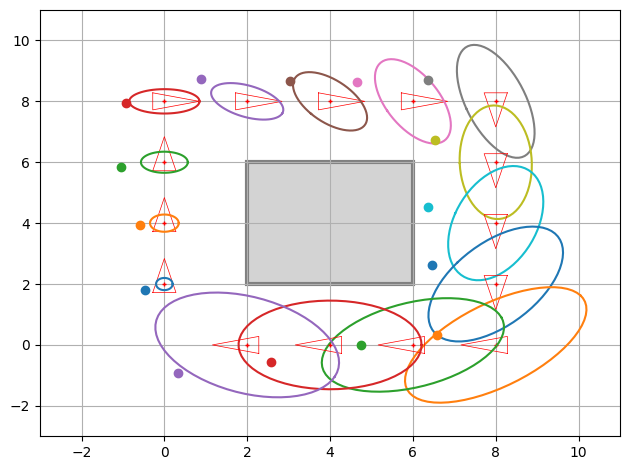

In [4]:
x = np.vstack([0., 0., np.pi/2]) # initial pose

# Probabilistic parameters
P = np.diag([0., 0., 0.])
Q = np.diag([0.04, 0.04, 0.01])

robot = Robot(x, P, Q)
demo_odometry_commands_analytical(robot)

### <font color="blue"><b><i>Thinking about it (1)</i></b></font>

Once you have completed this assignment regarding the analytical form of the odometry model, **answer the following questions**:

- Which is the difference between the $g_o(\cdot)$ function used here, and the one in the velocity model, $g_v(\cdot)$?

    La función $g_v$ calcula el movimiento usando velocidades (lineal y angular) sostenidas durante un intervalo de tiempo. En cambio, $g_o$ utiliza un incremento de pose estático directo ($\Delta x, \Delta y, \Delta \theta$) que ya ha sido medido por la odometría (los encoders de las ruedas), sin importar el tiempo que haya tardado.

- How many parameters compound the motion command $\mathbf{u}_t=\Delta\mathbf{x}_t^{\mathrm{odo}}$ in this model?

    Está compuesto por tres parámetros: el desplazamiento en el eje X ($\Delta x$), el desplazamiento en el eje Y ($\Delta y$) y el cambio de orientación ($\Delta \theta$).
    
- Which is the role of the Jacobians $\partial g_o / \partial \mathbf{x}_{t-1}$ and $\partial g_o / \partial \Delta\mathbf{x}_t^{\mathrm{odo}}$?

    Su función es "linealizar" la fórmula trigonométrica de la composición de poses. Esto permite proyectar matemáticamente cuánta incertidumbre proviene de la posición anterior del robot (J1) y cuánta incertidumbre nueva aporta el movimiento actual (J2) para poder sumarlas en una misma matriz de covarianza.

- What happens if you modify the covariance matrix $\Sigma_{\Delta\mathbf{x}_t^{\mathrm{odo}}}$ modeling the uncertainty in the motion command $\mathbf{u}_t=\Delta\mathbf{x}_t^{\mathrm{odo}}$? Try different values and discuss the results.

    Si aumentamos los valores de la diagonal de la matriz, la elipse de confianza dibujada crecerá muchísimo más rápido en cada paso, indicando que el robot está cada vez más "perdido". Además, la pose real (el punto de color) se desviará violentamente de la ruta ideal esperada.

## 3.3.2 Sample form

The analytical form used above, although useful for the probabilistic algorithms we will cover in this course, does not work well for sampling algorithms such as particle filters for localization.

The reason being, if we generate random samples from the Gaussian distributions as in the previous exercise, we will find some poses that are not feasible to the non-holonomic movement of a robot, i.e. they do not correspond to a velocity command $(v, \omega)$ with noise.

The following *sample form* is a more realistic way to generate samples of the robot pose. In this case, the movement of the robot is modeled as a sequence of actions (see Fig. 4):

1. **Turn** ($\theta_1$): to face the destination point.
2. **Advance** ($d$): to arrive at the destination.
3. **Turn** ($\theta_2$): to get to the desired angle.

<center><figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_motion/images/fig3-3-odometry_sample_form.png"  alt="">
  <figcaption>Fig. 4: Movement of a robot using odometry commands in sampling form.</figcaption>
</figure></center>

The odometry increment can also be represented as an equivalent sequence of an initial rotation, a straight-line translation, and a final rotation:

$$
\mathbf{u}_t^{\mathrm{odo}} =
\begin{bmatrix}
\bar{\theta}_1 \\
\bar{d} \\
\bar{\theta}_2
\end{bmatrix}
$$

These components can be computed from two consecutive odometry poses $\mathbf{x}_{t-1}^{\mathrm{odo}}$ and $\mathbf{x}_t^{\mathrm{odo}}$ as follows:

$$
\bar{\theta}_1 = \operatorname{atan2}(y_t^{\mathrm{odo}}-y_{t-1}^{\mathrm{odo}}, x_t^{\mathrm{odo}}-x_{t-1}^{\mathrm{odo}})-\theta_{t-1}^{\mathrm{odo}}
$$

$$
\bar{d} = \sqrt{(x_t^{\mathrm{odo}}-x_{t-1}^{\mathrm{odo}})^2+(y_t^{\mathrm{odo}}-y_{t-1}^{\mathrm{odo}})^2}
$$

$$
\bar{\theta}_2 = \theta_t^{\mathrm{odo}}-\theta_{t-1}^{\mathrm{odo}}-\bar{\theta}_1
$$

This model works by considering a set of possible robot poses $\{\mathbf{x}_{t-1}^{[i]}\}_{i=1}^N$. When a new odometry reading becomes available, the corresponding motion parameters $\mathbf{u}_t^{\mathrm{odo}}$ are computed from two consecutive odometry poses.

Then, the motion model $\mathbf{x}_t^{[i]}=g_o(\mathbf{x}_{t-1}^{[i]},\mathbf{u}_t^{\mathrm{odo}})$ is used to obtain the new set of poses $\{\mathbf{x}_{t}^{[i]}\}_{i=1}^N$, by applying a perturbed version of the odometry motion parameters to each particle, as we will see next.



### **<span style="color:green">ASSIGNMENT 2: Implementing the sampling form</span>**

Complete the following cells to experience the motion of a robot using the sampling form of the odometry model. For that:

1. Implement a function that, given the previously mentioned $\mathbf{x}_t^{\mathrm{odo}}$ and $\mathbf{x}_{t-1}^{\mathrm{odo}}$ generates an order $\mathbf{u}_t^{\mathrm{odo}} = [\bar{\theta}_1, \bar{d}, \bar{\theta}_2]^T$.


In [7]:
def generate_move(pose_now, pose_old):
    diff = pose_now - pose_old
    theta1 = np.arctan2(diff[1,0], diff[0,0]) - pose_old[2,0]
    d = np.sqrt(diff[0,0]**2 + diff[1,0]**2)
    theta2 = diff[2,0] - theta1
    return np.vstack((theta1, d, theta2))

**Try such function** with the code cell below:

In [8]:
generate_move(np.vstack([0., 0., 0.]), np.vstack([1., 1., np.pi/2]))

array([[-3.92699082],
       [ 1.41421356],
       [ 2.35619449]])

  Expected output for the commented example:

  ```
  array([[-3.92699082],
       [ 1.41421356],
       [ 2.35619449]])
  ```


2. Using the resulting odometry motion parameters $\mathbf{u}_t^{\mathrm{odo}} = [\bar{\theta}_1, \bar{d}, \bar{\theta}_2]^T$, we model their uncertainty by assuming that each component follows a **Gaussian distribution**:

$$\theta_1 \sim \mathcal{N}(\bar{\theta}_1, \sigma_{\theta_1}^2)$$

$$d \sim \mathcal{N}(\bar{d}, \sigma_d^2)$$

$$\theta_2 \sim \mathcal{N}(\bar{\theta}_2, \sigma_{\theta_2}^2)$$

Rather than using constant variances, we compute them as a function of the **amount of motion** and a set of parameters that characterize the robot's intrinsic noise:

$$\sigma_{\theta_1}^2 = \alpha_0 \bar{\theta}_1^2 + \alpha_1 \bar{d}^2$$

$$\sigma_d^2 = \alpha_2 \bar{d}^2 + \alpha_3 (\bar{\theta}_1^2 + \bar{\theta}_2^2)$$

$$\sigma_{\theta_2}^2 = \alpha_0 \bar{\theta}_2^2 + \alpha_1 \bar{d}^2$$

where $\boldsymbol{\alpha} = [\alpha_0,\dots,\alpha_3]^T$ (`a` in the code) contains the robot's intrinsic noise parameters. Thus, larger translations or rotations generally introduce greater uncertainty.

The noisy motion parameters can then be generated **independently for each sample** $i=1,\dots,N$ as:

$$\theta_1^{[i]} = \bar{\theta}_1 + \text{sample}(\sigma_{\theta_1}^2)$$

$$d^{[i]} = \bar{d} + \text{sample}(\sigma_d^2)$$

$$\theta_2^{[i]} = \bar{\theta}_2 + \text{sample}(\sigma_{\theta_2}^2)$$

where $\text{sample}(b^2)$ generates an independent random value from $\mathcal{N}(0,b^2)$ for each particle, with $b^2$ representing the variance. These are the components of the noisy motion $\tilde{\mathbf{u}}_t^{\mathrm{odo},[i]} = [\theta_1^{[i]}, d^{[i]}, \theta_2^{[i]}]^{T}
$

Thus, each particle receives a different realization of the same odometry motion, according to the uncertainty of its three components.

The motion model $\mathbf{x}_t^{[i]} = g_o(\mathbf{x}_{t-1}^{[i]},\tilde{\mathbf{u}}_t^{\mathrm{odo},[i]})$ is then applied to each particle using its corresponding sampled motion parameters:

$$x_t^{[i]} = x_{t-1}^{[i]} + d^{[i]}\cos(\theta_{t-1}^{[i]}+\theta_1^{[i]})$$

$$y_t^{[i]} = y_{t-1}^{[i]} + d^{[i]}\sin(\theta_{t-1}^{[i]}+\theta_1^{[i]})$$

$$\theta_t^{[i]} = \theta_{t-1}^{[i]}+\theta_1^{[i]}+\theta_2^{[i]}$$

Complete the `step()` and `draw()` methods to:
- Update the expected robot pose (`self.pose`) and generate new samples. The number of samples is set by `n_samples`, and `self.samples` is in charge of storing such samples. Each sample can be interpreted as one possible pose reached by the robot.
- Draw the true pose of the robot (without angle) as a cloud of particles (samples of possible points which the robot can be at).

Play a bit with different values of `a`. To improve this visualization the robot will move in increments of $0.5$ and we are going to plot the particles every 4 increments.

**Example**

<figure style="text-align:center">
  <img src="https://raw.githubusercontent.com/jotaraul/robotics_hub/main/robot_motion/images/fig3-3-2.png" width="400" alt="">
  <figcaption>Fig. 5: Movement of a robot using odometry commands in sampling form. <br/> Representing the expected pose (in red) and the samples (as clouds of dots) </figcaption>
</figure>


In [9]:
class SampledRobot(object):
    def __init__(self, mean, a, n_samples):
        self.pose = mean
        self.a = a
        self.samples = np.tile(mean, n_samples)

    def step(self, u):
        # Update pose (ideal)
        ang = self.pose[2, 0] + u[0, 0]
        self.pose[0, 0] += u[1, 0] * np.cos(ang)
        self.pose[1, 0] += u[1, 0] * np.sin(ang)
        self.pose[2, 0] = ang + u[2, 0]

        # Generate new samples (añadiendo el ruido según los parámetros a)
        sample = lambda b2: stats.norm(loc=0, scale=np.sqrt(b2)).rvs(size=self.samples.shape[1])
        u2 = u**2

        noisy_u = u + np.vstack((
            sample(self.a[0]*u2[0, 0] + self.a[1]*u2[1, 0]),
            sample(self.a[2]*u2[1, 0] + self.a[3]*(u2[0, 0] + u2[2, 0])),
            sample(self.a[0]*u2[2, 0] + self.a[1]*u2[1, 0])
        ))

        # Update particles (robots) poses
        ang = self.samples[2, :] + noisy_u[0, :]

        self.samples[0, :] += noisy_u[1, :] * np.cos(ang)
        self.samples[1, :] += noisy_u[1, :] * np.sin(ang)
        self.samples[2, :] = ang + noisy_u[2, :]

    def draw(self, fig, ax):
        DrawRobot(fig, ax, self.pose)
        # Dibujamos las partículas
        ax.plot(self.samples[0, :], self.samples[1, :], '.')

Run the following demo to **test your code**:

In [10]:
def demo_odometry_commands_sample(robot):
    # PARAMETERS
    inc = .5
    show_each = 4
    limit_iterations = 32

    # MATPLOTLIB
    fig, ax = plt.subplots()
    ax.set_xlim([-3, 11])
    ax.set_ylim([-3, 11])
    plt.ion()
    plt.grid()
    plt.tight_layout()

    # MAIN LOOP
    robot.draw(fig, ax)
    inc_pose = np.vstack((0., inc, 0.))

    for i in range(limit_iterations):
        if i == 16:
            inc_pose[0, 0] = inc
            inc_pose[1, 0] = 0
            inc_pose[2, 0] = -np.pi/2

        u = generate_move(robot.pose+inc_pose, robot.pose)

        robot.step(u)

        if i == 16:
            inc_pose[2, 0] = 0

        if i % show_each == show_each-1:
            robot.draw(fig, ax)
            clear_output(wait=True)
            display(fig)
            time.sleep(0.1)

    plt.close()

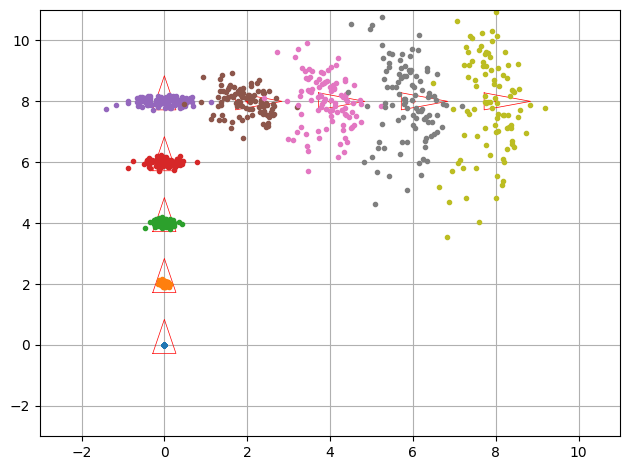

In [11]:
# RUN
n_particles = 100
a = np.array([.015, .0012, .003, .007])
x = np.vstack((0., 0., np.pi/2))

robot = SampledRobot(x, a, n_particles)
demo_odometry_commands_sample(robot)


### <font color="blue"><b><i>Thinking about it (2)</i></b></font>

Now you are an expert in the sample form of the odometry motion model! **Answer the following questions**:

- What is the effect of modifying the robot's intrinsic noise parameters $\boldsymbol{\alpha} = [\alpha_0,\dots,\alpha_3]^T$ (`a` in the code)?

    Cambiar los valores de $\boldsymbol{\alpha}$ modifica directamente cuánto error se inyecta en cada partícula en proporción a la distancia movida o al ángulo girado. Si aumentamos los valores, la nube de puntos se esparcirá y dispersará mucho más rápido por el mapa.

- How many components does the odometry motion input $\mathbf{u}_t^{\mathrm{odo}}$ contain?

    Contiene tres componentes en formato secuencial: rotación inicial ($\bar{\theta}_1$), traslación en línea recta ($\bar{d}$) y rotación final ($\bar{\theta}_2$).   

- After moving the robot a sufficient number of times, what shape does the distribution of samples take?

    Toma una forma de curva en media luna o "plátano" (banana shape). Esto ocurre por la cinemática no holonómica del robot: la incertidumbre en el giro inicial ($\theta_1$) causa que las partículas se abran en forma de abanico a medida que avanzan.   


## <font color="orange"><b><i>AI Appendix</i></b></font>

### A.1 How I used AI
- **Model/tool:**
  Gemini
- **What I asked AI to help with (bullets):**
  - Entender y multiplicar correctamente las matrices Jacobianas para el modelo analítico.
  - Implementar las ecuaciones de rotación-traslación (theta1, d, theta2) del modelo de muestreo.
  - Explicar la forma de "banana" que toma la distribución de partículas.
  - Vectorizar las actualizaciones del SampledRobot para evitar bucles for en Python.
- **Best prompt I used (paste):**
  "Explícame cómo aplicar ruido gaussiano dependiente del movimiento a un array de partículas 2D usando np.vstack y la función stats.norm de scipy, sin usar bucles for."
- **What I kept vs. changed from the AI output:**
  Adopté el código vectorizado sugerido por la IA para actualizar las partículas (samples[0,:], samples[1,:], samples[2,:]), pero ajusté manualmente los índices del vector a y u2 para que respetaran matemáticamente el sistema alpha0-alpha3 descrito en el cuaderno.

### A.2 AI review
Ask one generative AI to review your memo using this prompt:

```
Act as a technical reviewer of this robotics notebook. Read my memo and return exactly 5 bullet points:

- two on theory (key ideas),
- two on practice (relevant programming concepts of python used, not particular functions or variables),
- one on how to improve the code (most critical aspect: limitations, parameter choices, runtime/robustness, possible bugs).

Keep each bullet ≤15 words and make them specific to my work.
```

Paste its **5** items here:

- **(Theory 1)** AI claim:
  Los Jacobianos linealizan correctamente la composición de poses no lineales para propagar la covarianza.
- **(Theory 2)** AI claim:
  El modelo de muestreo modela con precisión la odometría como secuencias de rotación y traslación.
- **(Practice 1)** AI claim:
  La vectorización de NumPy actualiza las poses de todas las partículas simultáneamente sin bucles lentos.
- **(Practice 2)** AI claim:
  La función stats.norm maneja elegantemente la generación de distribuciones para múltiples partículas de golpe.
- **(Improvement)** AI claim:
  Preasignar memoria para las matrices de ruido podría mejorar el rendimiento en nubes grandes.

Finally, **do you agree with them?**, **would you have selected others?**
    Sí, totalmente de acuerdo. La vectorización en el modelo de partículas es crítica; generar el ruido de 100 partículas a la vez con stats.norm es exponencialmente más rápido que calcularlas una por una. También coincido en que si escalamos a miles de partículas, preasignar la memoria de las matrices (improvement) sería necesario para no saturar la RAM de Colab.